**Age Model Architecture**

input: image

output: age

regression model

Dataset: UTKFace
Link to download:

part 1: https://drive.usercontent.google.com/download?id=1mb5Z24TsnKI3ygNIlX6ZFiwUj0_PmpAW&export=download&authuser=0&confirm=t&uuid=ed8e8e51-cb3c-4262-8314-d96bb87781d0&at=APcXIO0mPgJPDxNgg9CQHXWo3U2S:1772484352669

part 2: https://drive.usercontent.google.com/download?id=19vdaXVRtkP-nyxz1MYwXiFsh_m_OL72b&export=download&authuser=0&confirm=t&uuid=95a6db6e-c371-4d68-8bd1-f39a6f0eb339&at=APcXIO1iISpyVwxBCULNYhXmO8zf:1772485135426


part 3: https://drive.usercontent.google.com/download?id=1oj9ZWsLV2-k2idoW_nRSrLQLUP3hus3b&export=download&authuser=0&confirm=t&uuid=f8223bbf-436b-4eb6-b67c-914e3f714db2&at=APcXIO1CzF8SjAoIUitQd7krPgcI:1772485183395

# Get the Data

In [1]:
!rm -rf datasets/

In [4]:
# Download and unzip the datasets from UTKface

import tarfile
import urllib.request
import os

download_url_part1 = "https://drive.usercontent.google.com/download?id=1mb5Z24TsnKI3ygNIlX6ZFiwUj0_PmpAW&export=download&authuser=0&confirm=t&uuid=ed8e8e51-cb3c-4262-8314-d96bb87781d0&at=APcXIO0mPgJPDxNgg9CQHXWo3U2S:1772484352669"
download_url_part2 = "https://drive.usercontent.google.com/download?id=19vdaXVRtkP-nyxz1MYwXiFsh_m_OL72b&export=download&authuser=0&confirm=t&uuid=95a6db6e-c371-4d68-8bd1-f39a6f0eb339&at=APcXIO1iISpyVwxBCULNYhXmO8zf:1772485135426"
download_url_part3 = "https://drive.usercontent.google.com/download?id=1oj9ZWsLV2-k2idoW_nRSrLQLUP3hus3b&export=download&authuser=0&confirm=t&uuid=f8223bbf-436b-4eb6-b67c-914e3f714db2&at=APcXIO1CzF8SjAoIUitQd7krPgcI:1772485183395"

# Download the datasets
download_urls = [download_url_part1, download_url_part2, download_url_part3]
face_path = os.path.join("datasets", "faces")
os.makedirs(face_path, exist_ok=True)

for dataset_num in range(len(download_urls)):
  dataset_folder_name = "part" + str(dataset_num + 1)
  if (not os.path.exists(os.path.join(face_path, dataset_folder_name)) and not os.path.exists(os.path.join(face_path, "images"))):
    print(f"Extracting dataset {dataset_num+1}...")
    faces_tar_location = os.path.join(face_path, "faces" + str(dataset_num+1) + ".tgz")
    urllib.request.urlretrieve(download_urls[dataset_num], faces_tar_location)

    # extract tar dataset
    faces_tgz = tarfile.open(faces_tar_location)
    faces_tgz.extractall(path="datasets/faces")
    faces_tgz.close()

    # remove tar file
    os.remove(faces_tar_location)

  else:
    print(f"dataset {dataset_num+1} already exists")



Extracting dataset 1...
Extracting dataset 2...
Extracting dataset 3...


In [6]:
# Combine all data into one folder
import shutil

faces_images_path = os.path.join(face_path, "images")
os.makedirs(faces_images_path, exist_ok=True)

# Get source folders to copy image data from
source_folders = []
for dataset in range(len(download_urls)):
  dataset_path = os.path.join("./datasets/faces/part" + str(dataset+1))
  if (os.path.exists(dataset_path)):
    source_folders.append(dataset_path)

for folder in source_folders:
  file_names = os.listdir(folder)
  for file_name in file_names:
    shutil.move(os.path.join(folder, file_name), faces_images_path)
  os.rmdir(folder) # remove directory because we don't need it anymore

In [5]:
file_names = os.listdir(faces_images_path)
print(f"Number of images: {len(file_names)}")

Number of images: 24109


Cropping Images

# Creating CSV
Create CSV table of the whole data set so we know what parameters to use. Extract

In [18]:
%pip install pandas
%pip install Pillow
%pip install matplotlib
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 3.4 MB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [13]:
import os
import pandas as pd
from PIL import Image

# Define the path to the images
image_dir = 'cropped/'
file_list = [f for f in os.listdir(image_dir) if f.endswith('.jpg')]

data_list = []

print(f"Found {len(file_list)} images. Starting processing...")

for filename in file_list:
    # Parse filename: [age]_[gender]_[race]_[date&time].jpg
    parts = filename.replace('.jpg', '').split('_')

    # We only need the first part (age)
    if len(parts) >= 1:
        try:
            age_str = parts[0]

            # Open image to get dimensions
            img_path = os.path.join(image_dir, filename)
            with Image.open(img_path) as img:
                width, height = img.size

            data_list.append({
                'file_name': filename,
                'age': int(age_str),
                'height': height,
                'width': width
            })
        except Exception as e:
            print(f"Error processing {filename}: {e}")
    else:
        print(f"Skipping {filename}: Unexpected format")

# Create DataFrame
df = pd.DataFrame(data_list)

# Save to CSV
df.to_csv('dataSpecs.csv', index=False)
print(f"Successfully saved {len(df)} entries to dataSpecs.csv")

# Display the first few rows
display(df.head())

Found 176753 images. Starting processing...
Successfully saved 176753 entries to dataSpecs.csv


,file_name,age,height,width
0,51_Wesley_Snipes_0012.jpg,51,256,256
1,45_Amy_Sedaris_0009.jpg,45,256,256
2,34_50_Cent_0014.jpg,34,256,256
3,56_Joan_Allen_0012.jpg,56,256,256
4,20_Mae_Whitman_0014.jpg,20,256,256


In [14]:
import os

image_dir = 'cropped'
all_files = os.listdir(image_dir)
non_jpg_files = [f for f in all_files if not f.lower().endswith('.jpg')]

print(f"Total files in directory: {len(all_files)}")
print(f"Non-JPG files found ({len(non_jpg_files)}):")
for f in non_jpg_files:
    print(f" - {f}")

Total files in directory: 176753
Non-JPG files found (0):


--- Statistical Summary ---


,age,height,width
count,176753.000000,176753.0,176753.0
mean,37.354002,256.0,256.0
std,13.219063,0.0,0.0
min,1.000000,256.0,256.0
25%,27.000000,256.0,256.0
50%,37.000000,256.0,256.0
75%,47.000000,256.0,256.0
max,116.000000,256.0,256.0
mode,26.000000,256.0,256.0


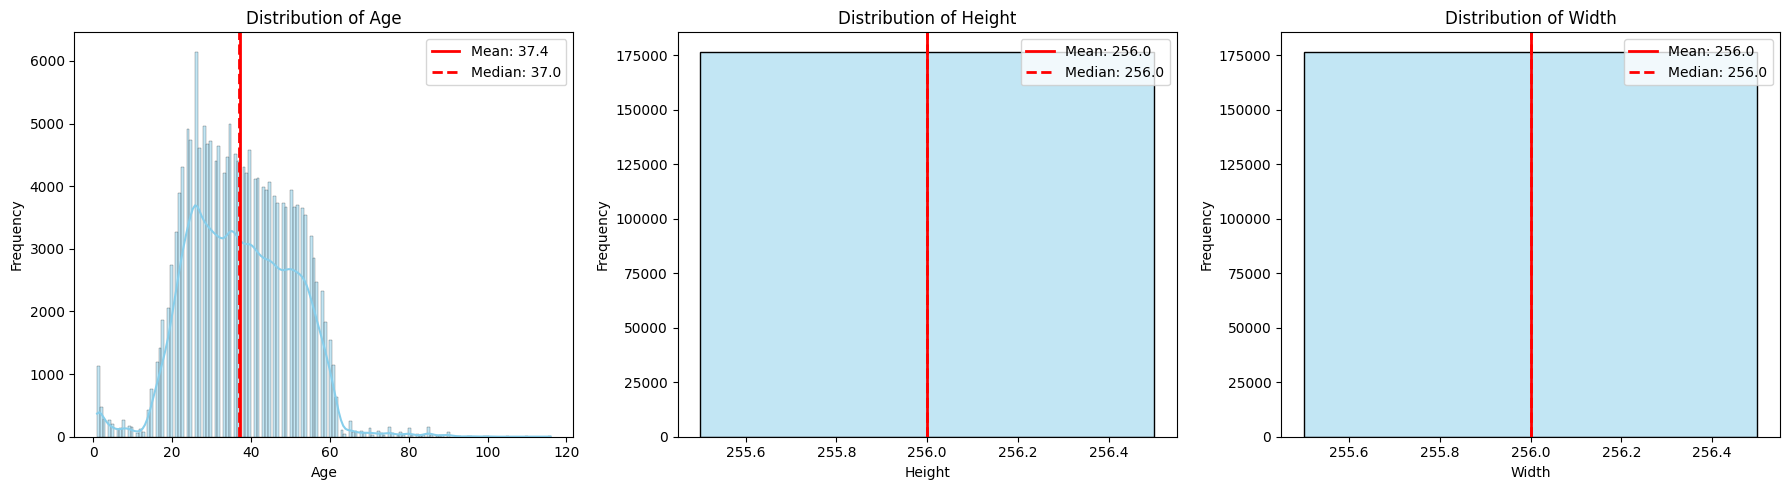

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('dataSpecs.csv')

# Define the metrics we want to analyze
metrics = ['age', 'height', 'width']

# 1. Print Statistical Summary
print("--- Statistical Summary ---")
stats = df[metrics].describe()
mode = df[metrics].mode().iloc[0].to_frame().T
mode.index = ['mode']
summary = pd.concat([stats, mode])
display(summary)

# 2. Plot Distributions with Mean and Median lines
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, metric in enumerate(metrics):
    sns.histplot(df[metric], kde=True, ax=axes[i], color='skyblue')

    mean_val = df[metric].mean()
    median_val = df[metric].median()

    # Add vertical lines for mean and median
    axes[i].axvline(mean_val, color='red', linestyle='-', linewidth=2, label=f'Mean: {mean_val:.1f}')
    axes[i].axvline(median_val, color='red', linestyle='--', linewidth=2, label=f'Median: {median_val:.1f}')

    axes[i].set_title(f'Distribution of {metric.capitalize()}')
    axes[i].set_xlabel(metric.capitalize())
    axes[i].set_ylabel('Frequency')
    axes[i].legend()

plt.tight_layout()
plt.show()